<a href="https://colab.research.google.com/github/sajivjose174/insurance-premium-predictor/blob/main/Insurance_Cost_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Insurance Cost Prediction

##Problem Statement:

Insurance companies need to accurately predict the cost of health insurance for individuals to set premiums appropriately. However, traditional methods of cost prediction often rely on broad actuarial tables and historical averages, which may not account for the nuanced differences among individuals.By leveraging machine learning techniques, insurers can predict more accurately the insurance costs tailored to individual profiles, leading to more competitive pricing and better risk management.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import gdown

file_id = "1NBk1TFkK4NeKdodR2DxIdBp2Mk1mh4AS"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "data.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1NBk1TFkK4NeKdodR2DxIdBp2Mk1mh4AS
To: /content/data.csv
100%|██████████| 30.8k/30.8k [00:00<00:00, 34.4MB/s]


'data.csv'

In [ ]:
df = pd.read_csv("data.csv")
df.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      986 non-null    int64
 1   Diabetes                 986 non-null    int64
 2   BloodPressureProblems    986 non-null    int64
 3   AnyTransplants           986 non-null    int64
 4   AnyChronicDiseases       986 non-null    int64
 5   Height                   986 non-null    int64
 6   Weight                   986 non-null    int64
 7   KnownAllergies           986 non-null    int64
 8   HistoryOfCancerInFamily  986 non-null    int64
 9   NumberOfMajorSurgeries   986 non-null    int64
 10  PremiumPrice             986 non-null    int64
dtypes: int64(11)
memory usage: 84.9 KB


In [ ]:
df.columns

Index(['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants',
       'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies',
       'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'PremiumPrice'],
      dtype='object')

In [ ]:
df.shape

(986, 11)

In [ ]:
df.describe()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
count,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000
mean,41.745436,0.419878,0.468560,0.055781,0.180527,168.182556,76.950304,0.215010,0.117647,0.667343,24336.713996
std,13.963371,0.493789,0.499264,0.229615,0.384821,10.098155,14.265096,0.411038,0.322353,0.749205,6248.184382
min,18.000000,0.000000,0.000000,0.000000,0.000000,145.000000,51.000000,0.000000,0.000000,0.000000,15000.000000
25%,30.000000,0.000000,0.000000,0.000000,0.000000,161.000000,67.000000,0.000000,0.000000,0.000000,21000.000000
50%,42.000000,0.000000,0.000000,0.000000,0.000000,168.000000,75.000000,0.000000,0.000000,1.000000,23000.000000
75%,53.000000,1.000000,1.000000,0.000000,0.000000,176.000000,87.000000,0.000000,0.000000,1.000000,28000.000000
max,66.000000,1.000000,1.000000,1.000000,1.000000,188.000000,132.000000,1.000000,1.000000,3.000000,40000.000000


In [ ]:
df.isnull().sum()

,0
Age,0
Diabetes,0
BloodPressureProblems,0
AnyTransplants,0
AnyChronicDiseases,0
Height,0
Weight,0
KnownAllergies,0
HistoryOfCancerInFamily,0
NumberOfMajorSurgeries,0


In [ ]:
##No nulls

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
##No duplicates.

In [ ]:
#Feature Engineering (BMI):

df['BMI'] = df['Weight'] / ((df['Height']/100)**2)

In [ ]:
#BMI combines height and weight into a meaningful health indicator, which is more predictive of insurance risk than using them separately.

In [ ]:
df['BMI']

,BMI
0,23.725286
1,22.530864
2,23.634033
3,27.770313
4,31.934969
...,...
981,23.458562
982,29.903029
983,29.552549
984,29.242109


#Exploratory Data Analysis

In [ ]:
for i in df.columns:
  print (f"{i}:", df[i].nunique())

Age: 49
Diabetes: 2
BloodPressureProblems: 2
AnyTransplants: 2
AnyChronicDiseases: 2
Height: 44
Weight: 74
KnownAllergies: 2
HistoryOfCancerInFamily: 2
NumberOfMajorSurgeries: 4
PremiumPrice: 24
BMI: 751


In [ ]:
for i in df.columns:
  print (f"{i}:", df[i].value_counts())

Age: Age
43    30
27    27
42    27
35    26
45    25
59    25
48    24
25    24
44    24
46    23
18    23
66    23
33    23
49    23
64    22
24    22
30    22
29    22
47    22
32    22
62    21
21    21
19    21
51    20
50    20
31    20
54    20
40    19
22    19
52    19
36    19
63    19
37    18
41    18
34    18
38    17
60    17
55    17
65    17
53    17
20    17
28    17
58    16
61    16
56    15
26    13
23    13
57    12
39    11
Name: count, dtype: int64
Diabetes: Diabetes
0    572
1    414
Name: count, dtype: int64
BloodPressureProblems: BloodPressureProblems
0    524
1    462
Name: count, dtype: int64
AnyTransplants: AnyTransplants
0    931
1     55
Name: count, dtype: int64
AnyChronicDiseases: AnyChronicDiseases
0    808
1    178
Name: count, dtype: int64
Height: Height
166    42
164    42
165    38
174    38
175    35
163    34
176    34
170    32
169    32
168    31
172    29
167    29
179    28
177    28
178    28
162    27
159    27
156    27
173    26
161    26

##Graphical Analysis:

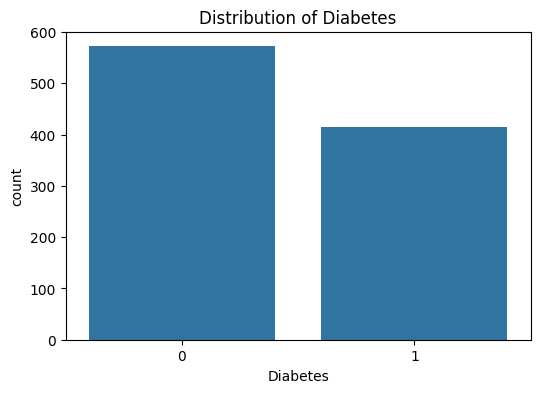

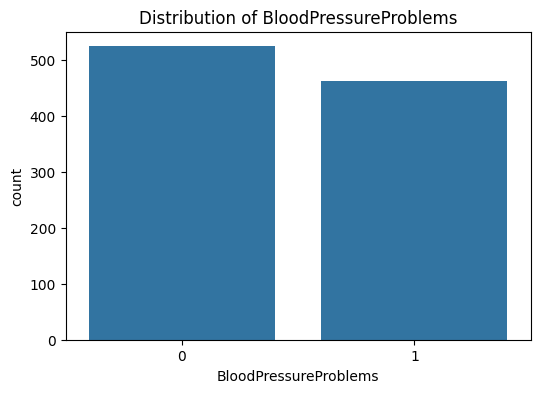

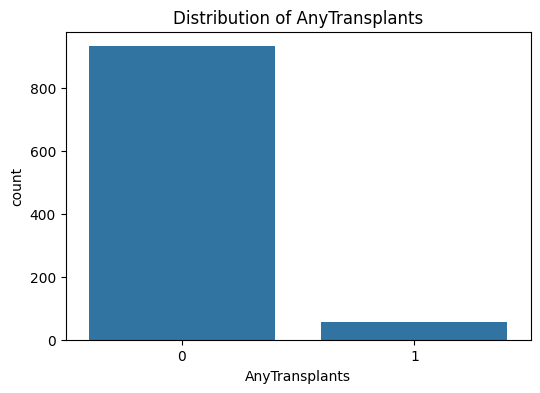

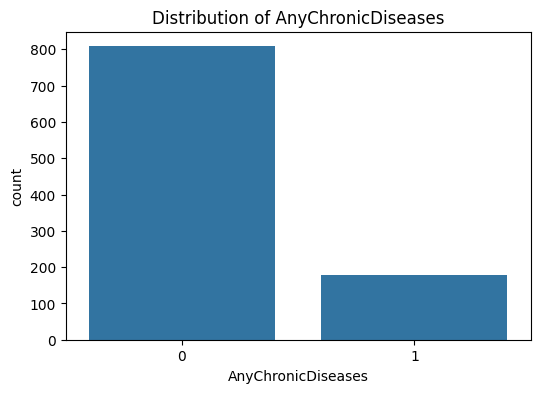

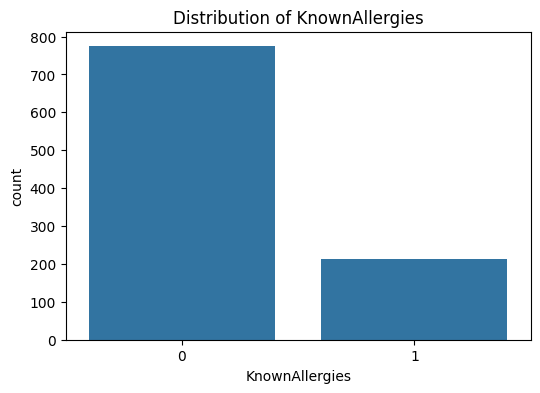

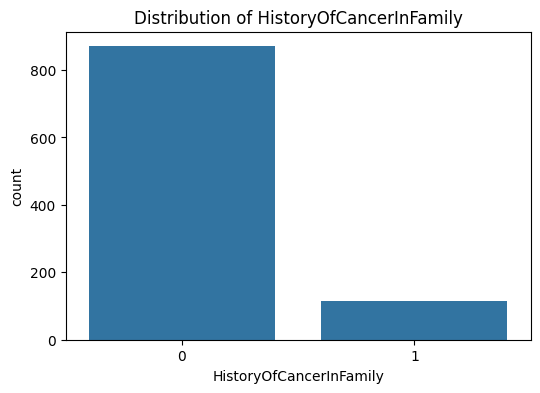

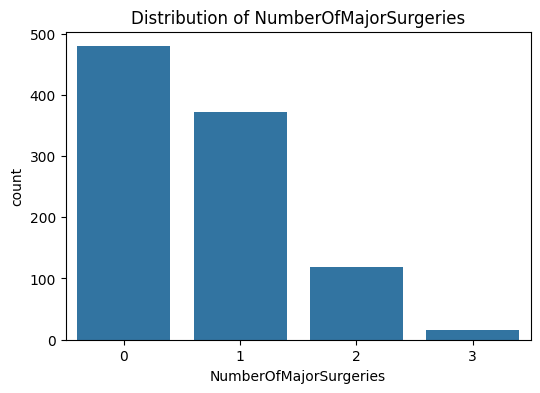

In [ ]:
#Barplot

categorical_cols = ['Diabetes', 'BloodPressureProblems', 'AnyTransplants', 'AnyChronicDiseases', 'KnownAllergies', 'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries']

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.show()

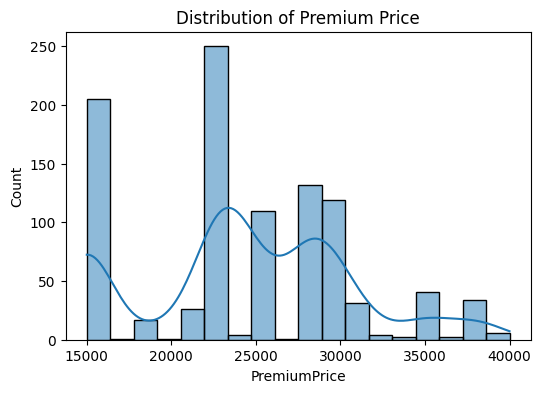

In [ ]:
#Premium Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['PremiumPrice'], kde=True)
plt.title("Distribution of Premium Price")
plt.show()

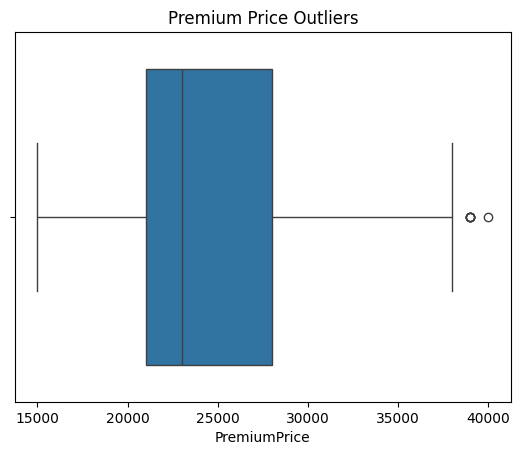

In [ ]:
#Outliers:
sns.boxplot(x=df['PremiumPrice'])
plt.title("Premium Price Outliers")
plt.show()

In [ ]:
##right skewed plot.

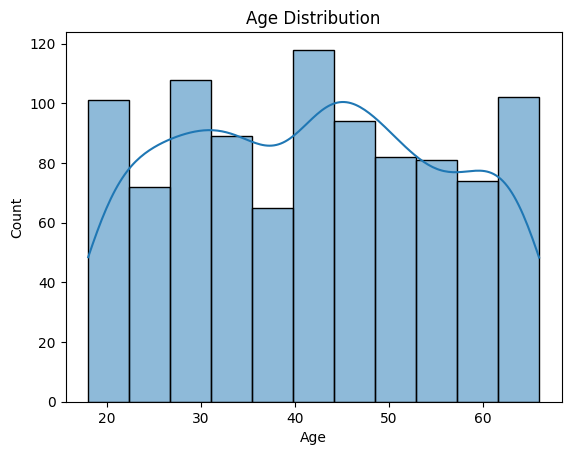

In [ ]:
#Age distrubution
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

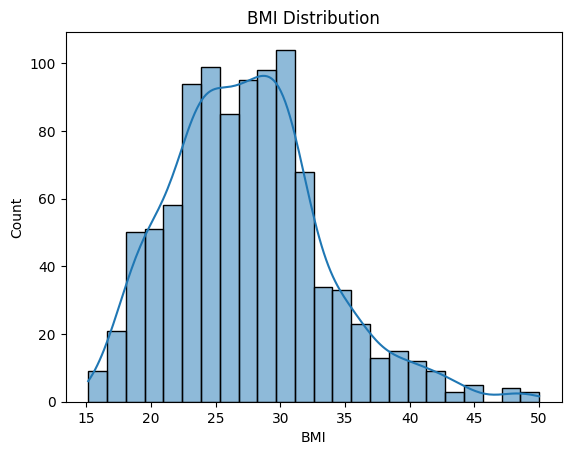

In [ ]:
# BMI distribution:
sns.histplot(df['BMI'], kde=True)
plt.title("BMI Distribution")
plt.show()

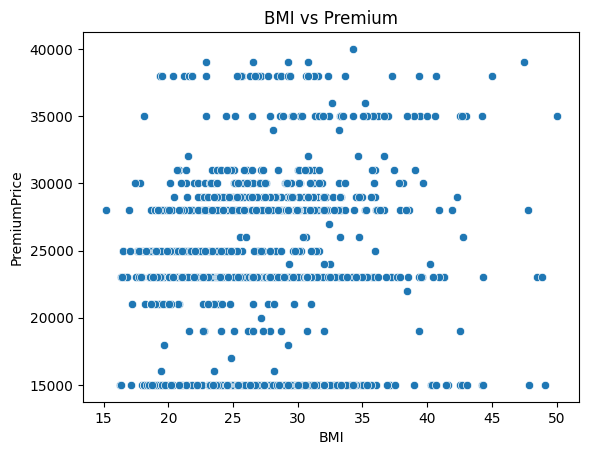

In [ ]:
#BMI vs Premium scatter plot
sns.scatterplot(x='BMI', y='PremiumPrice', data=df)
plt.title("BMI vs Premium")
plt.show()

In [ ]:
#scatter plot can look noisy.

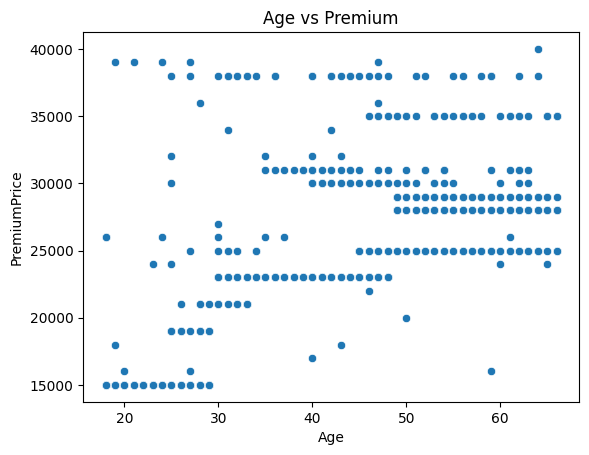

In [ ]:
#Age vs Premium scatter plot

sns.scatterplot(x='Age', y='PremiumPrice', data=df)
plt.title("Age vs Premium")
plt.show()

In [ ]:
#scatter plot can look noisy.

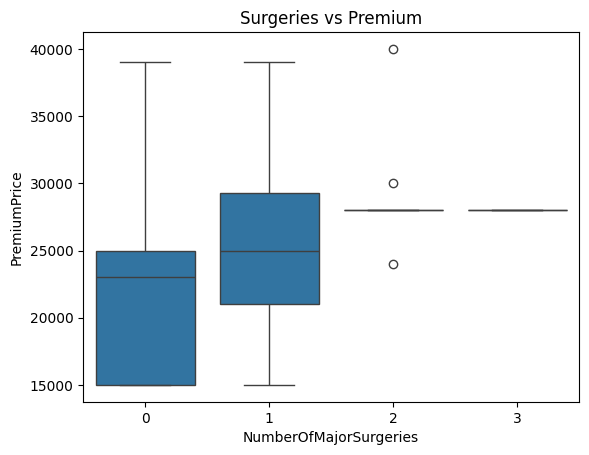

In [ ]:
sns.boxplot(x='NumberOfMajorSurgeries', y='PremiumPrice', data=df)
plt.title("Surgeries vs Premium")
plt.show()

In [ ]:
#Individuals with a higher number of major surgeries tend to have higher median insurance premiums.
#The boxplot shows a clear upward shift in median premium as the number of major surgeries increases.
#This suggests a strong positive association between surgical history and insurance cost.

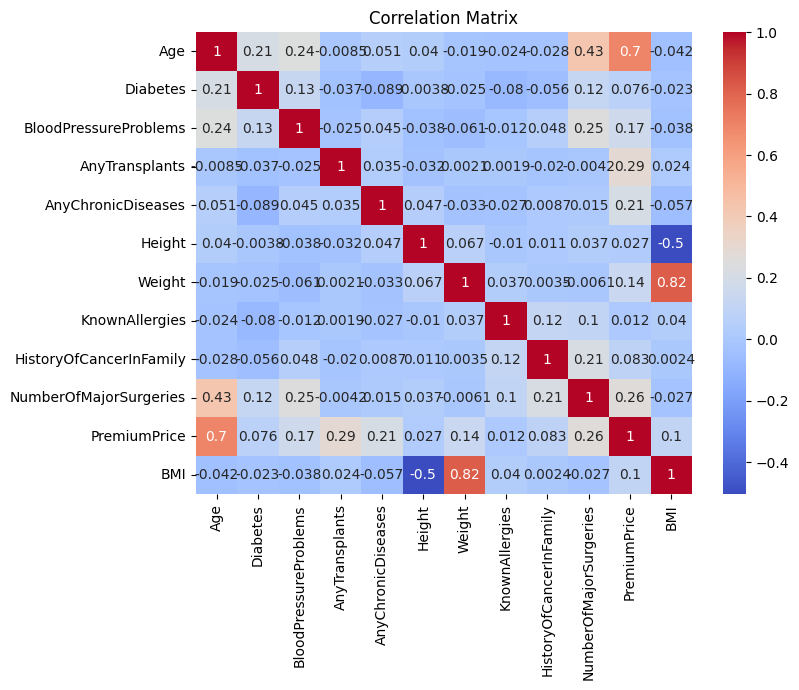

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

####Correlation analysis reveals that age is the most significant predictor of insurance premium, followed by medical risk factors such as number of surgeries, transplants, and chronic diseases. Physical attributes like BMI and height show minimal influence, suggesting that insurers prioritize medical history over body characteristics when determining premiums.

In [ ]:
df.columns

Index(['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants',
       'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies',
       'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'PremiumPrice',
       'BMI'],
      dtype='object')

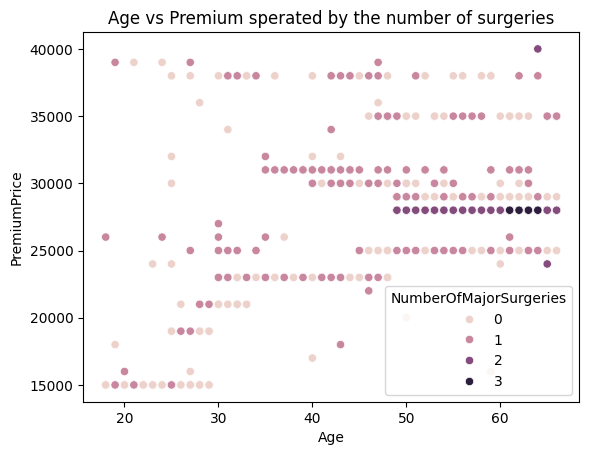

In [ ]:
sns.scatterplot(x='Age', y='PremiumPrice', hue='NumberOfMajorSurgeries',data=df)
plt.title("Age vs Premium sperated by the number of surgeries")
plt.show()

In [ ]:
Q1 = df['PremiumPrice'].quantile(0.25)
Q3 = df['PremiumPrice'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['PremiumPrice'] < Q1 - 1.5*IQR) |(df['PremiumPrice'] > Q3 + 1.5*IQR)]

print(len(outliers))

6


In [ ]:
#only 6 outliers so retaining them is a good option, they might be high risk individuals which can be used for accurate modelling.

#Hypothesis Testing:

In [ ]:
#Hypo-test to see if Diabetes is significant to Premium Price.

group1 = df[df['Diabetes'] == 0]['PremiumPrice']
group2 = df[df['Diabetes'] == 1]['PremiumPrice']
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(group1, group2)
print("p-value:", p_value)

if p_value<0.05:
  print('Significant difference')
else:
  print('No significant difference')

p-value: 0.01669009138530611
Significant difference


In [ ]:
#Hypo-test to see if AnyChronicDiseases is significant to Premium Price.
group1 = df[df['AnyChronicDiseases'] == 0]['PremiumPrice']
group2 = df[df['AnyChronicDiseases'] == 1]['PremiumPrice']

t_stat, p_value = ttest_ind(group1, group2)
print("p-value:", p_value)
if p_value<0.05:
  print('Significant difference')
else:
  print('No significant difference')

p-value: 3.713413765291482e-11
Significant difference


In [ ]:
group0 = df[df['NumberOfMajorSurgeries'] == 0]['PremiumPrice']
group1 = df[df['NumberOfMajorSurgeries'] == 1]['PremiumPrice']
group2 = df[df['NumberOfMajorSurgeries'] == 2]['PremiumPrice']
group3 = df[df['NumberOfMajorSurgeries'] == 3]['PremiumPrice']

In [ ]:
from scipy.stats import levene
#Hypo-test to see if NumberOfMajorSurgeries is significant to Premium Price.
stat, p = levene(group0, group1, group2, group3)
print("p-value:", p)
if p_value<0.05:
  print('variances NOT equal')
else:
  print('variances equal')

p-value: 3.877645981882467e-34
variances NOT equal


In [ ]:
#from scipy.stats import f_oneway
from scipy.stats import kruskal

stat, p_value = kruskal(group0, group1, group2, group3)
print("p-value:", p_value)
if p_value<0.05:
  print('Significant difference')
else:
  print('No significant difference')

p-value: 3.3223412749827346e-20
Significant difference


In [ ]:
#Hypo-test to see if KnownAllergies is significant to Premium Price.
group1 = df[df['KnownAllergies'] == 0]['PremiumPrice']
group2 = df[df['KnownAllergies'] == 1]['PremiumPrice']

t_stat, p_value = ttest_ind(group1, group2)
print("p-value:", p_value)
if p_value<0.05:
  print('Significant difference')
else:
  print('No significant difference')

p-value: 0.7042667378180334
No significant difference


In [ ]:
#Hypo-test to see if HistoryOfCancerInFamily is significant to Premium Price.

group1 = df[df['HistoryOfCancerInFamily'] == 0]['PremiumPrice']
group2 = df[df['HistoryOfCancerInFamily'] == 1]['PremiumPrice']

t_stat, p_value = ttest_ind(group1, group2)
print("p-value:", p_value)
if p_value<0.05:
  print('Significant difference')
else:
  print('No significant difference')

p-value: 0.009005587310447026
Significant difference


In [ ]:
#Hypo-test to see if AnyTransplants is significant to Premium Price.

group1 = df[df['AnyTransplants'] == 0]['PremiumPrice']
group2 = df[df['AnyTransplants'] == 1]['PremiumPrice']

t_stat, p_value = ttest_ind(group1, group2)
print("p-value:", p_value)
if p_value<0.05:
  print('Significant difference')
else:
  print('No significant difference')

p-value: 1.9787295423632772e-20
Significant difference


###Hypothesis testing reveals that medical risk factors play a critical role in determining insurance premiums. Factors such as number of surgeries, transplant history, and chronic diseases show a strong and statistically significant impact on premium pricing. Diabetes and family history of cancer also demonstrate significant influence, though to a lesser extent. In contrast, variables like BMI and known allergies do not show a significant relationship with premium costs. These findings suggest that insurance pricing is primarily driven by serious medical conditions and historical health risks rather than general physical attributes.

In [ ]:
X = df.drop('PremiumPrice', axis=1)
y = df['PremiumPrice']

In [ ]:
#trian-test split:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Scaling:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Linear_Regression model as base:

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred_lr = model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 3494.4137981898157
Linear Regression R2: 0.713646143964974


###Model performs decently well on with the base model. But explortaion for different models would be benefical.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 2135.170728631329
Random Forest R2: 0.8930896905551489


In [ ]:
from sklearn.metrics import r2_score

# Train predictions
y_train_pred = rf.predict(X_train)
# Train score
train_r2 = r2_score(y_train, y_train_pred)

test_r2 = r2_rf
print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.9672751954519283
Test R2: 0.8930896905551489


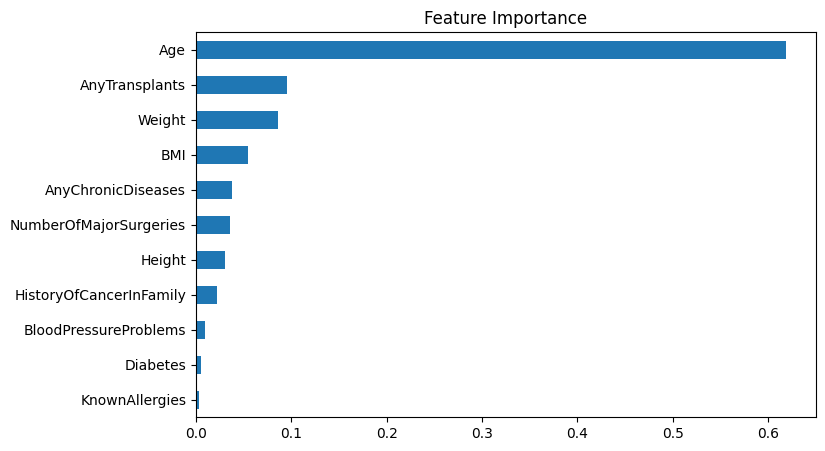

In [ ]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5, scoring='r2')

print("Cross-validation R2:", scores.mean())

Cross-validation R2: 0.7861516583440542


In [ ]:
!pip install xgboost

In [ ]:
#XG-Boost:

from xgboost import XGBRegressor
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R2:", r2_xgb)

XGBoost RMSE: 2715.0490787460913
XGBoost R2: 0.8271339535713196


In [ ]:
# Train predictions
y_train_pred = xgb.predict(X_train)
# Train score
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_xgb
print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.9997351169586182
Test R2: 0.8271339535713196


###While the baseline model of Linear Regression performs decently well, more models were explored. Data was fit on Random Forest and XG-Boost. The train and test score, R2 and rsme were compared to check for best performance. XG-boost had a classic case of overfitting, while random forest was good overall.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {'n_estimators': [100, 200],'max_depth': [5, 10, None],'min_samples_split': [2, 5],'min_samples_leaf': [1, 2]}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(rf,param_grid,cv=3,scoring='r2',n_jobs=-1)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
best_rf = grid.best_estimator_

y_pred_tuned = best_rf.predict(X_test)
print("Tuned RF R2:", r2_score(y_test, y_pred_tuned))

Tuned RF R2: 0.9022835395863364


In [ ]:
# Train predictions
y_train_pred = best_rf.predict(X_train)
# Train score
train_r2 = r2_score(y_train, y_train_pred)
r2_fit=r2_score(y_test, y_pred_tuned)
test_r2 = r2_fit
print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.9061982707604902
Test R2: 0.9022835395863364


###Hyper-parameter tuning was done to achieve the best possible model while enusirng that generalisation happens.The minimal gap between training and testing performance indicates that the model generalizes exceptionally well and does not suffer from overfitting.

Recommendede to use: Random Forest with the best hyper-parameter.

In [ ]:
residuals = y_test - y_pred_rf
std_error = np.std(residuals)
lower = y_pred_rf - 1.96 * std_error
upper = y_pred_rf + 1.96 * std_error
for i in range(5):
    print(f"Prediction: {y_pred_rf[i]:.2f}, Interval: [{lower[i]:.2f}, {upper[i]:.2f}]")

Prediction: 29750.00, Interval: [25565.13, 33934.87]
Prediction: 30150.00, Interval: [25965.13, 34334.87]
Prediction: 30230.00, Interval: [26045.13, 34414.87]
Prediction: 16570.00, Interval: [12385.13, 20754.87]
Prediction: 23100.00, Interval: [18915.13, 27284.87]


###Prediction intervals were generated using residual standard error to quantify uncertainty in model predictions. For example, a predicted premium of ₹29,750 was associated with a 95% prediction interval of ₹25,565 to ₹33,934. This indicates that while the model provides accurate point estimates, there is inherent variability in predictions, which is important for real-world decision-making.

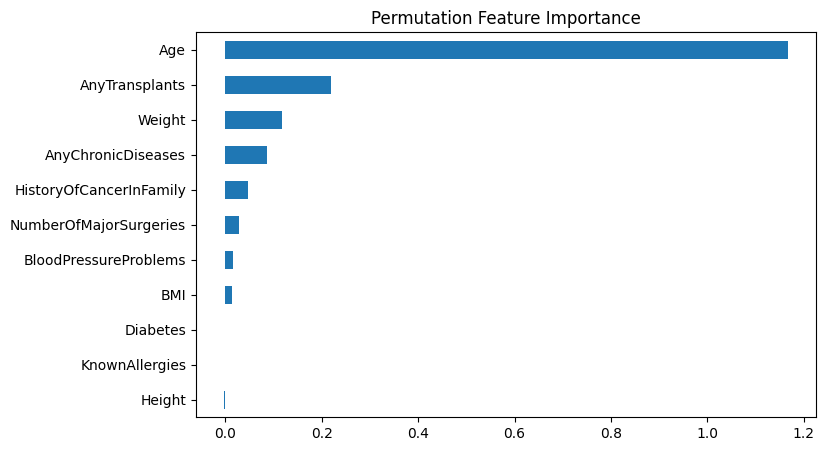

In [ ]:
#Permutation Importance:

from sklearn.inspection import permutation_importance

result = permutation_importance(best_rf, X_test, y_test,n_repeats=10,random_state=42,n_jobs=-1)

import pandas as pd

importance = pd.Series(result.importances_mean, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,5))

plt.title("Permutation Feature Importance")
plt.show()

**Insights:**


1.Insurance companies primarily base premium pricing on age and serious medical conditions such as transplants and chronic diseases, rather than general health indicators like BMI or allergies. This enables more accurate risk-based pricing strategies.

2.Permutation feature importance analysis revealed that age is the most influential factor in predicting insurance premiums, followed by transplant history and chronic diseases.

3.Although the number of surgeries was found to be statistically significant in hypothesis testing, feature importance analysis from the Random Forest model indicates that its predictive contribution is relatively lower compared to age and transplant history. As a result, small changes in the number of surgeries may not significantly impact predicted premiums. This highlights the distinction between statistical significance and model-based importance in predictive modeling.


4.The Random Forest model demonstrated strong generalization with minimal difference between training and testing performance after hyperparameter tuning. This indicates that the model is stable and does not suffer from overfitting.



5.Hyperparameter tuning improved model performance slightly while significantly reducing overfitting. It also led to more reliable feature importance estimates by emphasizing the most relevant predictors.




**Recommendations:**



1.Risk-Based Pricing Strategy:

Insurance companies should prioritize age and major medical conditions such as transplants and chronic diseases when determining premiums, as these are the strongest drivers of cost.

2.Targeted Risk Segmentation:
Customers can be segmented into risk categories based on age and medical history, allowing insurers to design personalized pricing and policies for different risk groups.

3.Avoid Overweighting Minor Factors:

Factors such as BMI and allergies should not be heavily weighted in pricing models, as they show low predictive and statistical significance.


4.Future models can incorporate lifestyle data such as smoking habits, exercise levels, and occupation to further improve prediction accuracy.

##Streamlit:

In [ ]:
#import joblib
#joblib.dump(best_rf, "model.pkl")

['model.pkl']

In [ ]:
#from google.colab import files
#files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>